In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
weight = 0.3
bias = 0.9

In [4]:
X = torch.arange(start = 0,end = 1,step = 0.01).unsqueeze(dim = 1)
X

tensor([[0.0000],
        [0.0100],
        [0.0200],
        [0.0300],
        [0.0400],
        [0.0500],
        [0.0600],
        [0.0700],
        [0.0800],
        [0.0900],
        [0.1000],
        [0.1100],
        [0.1200],
        [0.1300],
        [0.1400],
        [0.1500],
        [0.1600],
        [0.1700],
        [0.1800],
        [0.1900],
        [0.2000],
        [0.2100],
        [0.2200],
        [0.2300],
        [0.2400],
        [0.2500],
        [0.2600],
        [0.2700],
        [0.2800],
        [0.2900],
        [0.3000],
        [0.3100],
        [0.3200],
        [0.3300],
        [0.3400],
        [0.3500],
        [0.3600],
        [0.3700],
        [0.3800],
        [0.3900],
        [0.4000],
        [0.4100],
        [0.4200],
        [0.4300],
        [0.4400],
        [0.4500],
        [0.4600],
        [0.4700],
        [0.4800],
        [0.4900],
        [0.5000],
        [0.5100],
        [0.5200],
        [0.5300],
        [0.5400],
        [0

In [5]:
y  = weight * X + bias

In [6]:
print(f"Number of X samples: {len(X)}")
print(f"Number of y samples: {len(y)}")

Number of X samples: 100
Number of y samples: 100


In [7]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:],y[train_split:]

In [8]:
def plot_predictions(train_data = X_train,
                 train_labels = y_train,
                 test_data = X_test,
                 test_labels = y_test,
                 predictions = None):
  plt.figure(figsize = (10,7))
  plt.scatter(train_data,train_labels,c = 'b',s = 4,label = "Training data")
  plt.scatter(test_data,test_labels,c = 'g',s = 4,label = "Test data")

  if predictions is not None:
    plt.scatter(test_data,predictions,c = 'r',s = 4,label = "Predictions")
  plt.legend(prop = {"size" : 14})

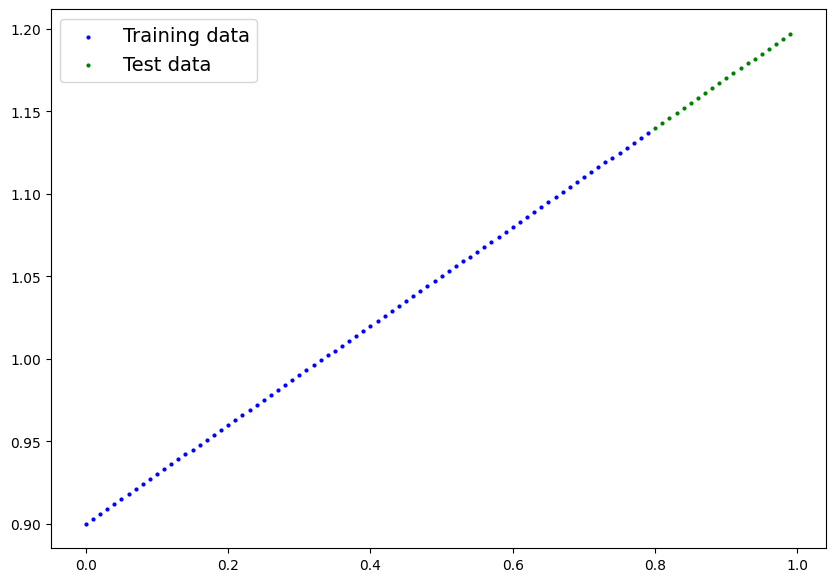

In [9]:
plot_predictions()

In [10]:
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.linear_layer = nn.Linear(in_features=1,
                                  out_features=1)

  def forward(self,x: torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)

In [11]:
torch.manual_seed(42)
model_1 = LinearRegressionModel()

In [12]:
next(model_1.parameters()).device

device(type='cpu')

In [13]:
model_1.to(device)

LinearRegressionModel(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [14]:
list(model_1.parameters())

[Parameter containing:
 tensor([[0.7645]], device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([0.8300], device='cuda:0', requires_grad=True)]

In [15]:
loss_fn = nn.L1Loss()

In [16]:
optimizer = torch.optim.SGD(params = model_1.parameters(),
                            lr = 0.001)

In [ ]:
torch.manual_seed(42)

epochs = 3000

X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)


for epoch in range(epochs):

  model_1.train()

  y_pred = model_1(X_train)

  loss = loss_fn(y_pred,y_train)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  if epoch % 20 == 0 :
    model_1.eval()

    with torch.inference_mode():
      y_preds = model_1(X_test)

      test_loss = loss_fn(y_preds,y_test)

      print(f"Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss}")




Epoch: 0 | Loss: 0.1275613158941269 | Test Loss: 0.3448432385921478
Epoch: 20 | Loss: 0.11831317096948624 | Test Loss: 0.326911598443985
Epoch: 40 | Loss: 0.11067219078540802 | Test Loss: 0.3105461299419403
Epoch: 60 | Loss: 0.10435488075017929 | Test Loss: 0.29557040333747864
Epoch: 80 | Loss: 0.09914900362491608 | Test Loss: 0.2819482982158661
Epoch: 100 | Loss: 0.09486338496208191 | Test Loss: 0.2695785462856293
Epoch: 120 | Loss: 0.09132411330938339 | Test Loss: 0.25835609436035156
Epoch: 140 | Loss: 0.08837442100048065 | Test Loss: 0.24817030131816864
Epoch: 160 | Loss: 0.08593379706144333 | Test Loss: 0.2389678806066513
Epoch: 180 | Loss: 0.08385944366455078 | Test Loss: 0.23059974610805511
Epoch: 200 | Loss: 0.08210650831460953 | Test Loss: 0.22307220101356506
Epoch: 220 | Loss: 0.08060416579246521 | Test Loss: 0.21626321971416473
Epoch: 240 | Loss: 0.07928529381752014 | Test Loss: 0.21007739007472992
Epoch: 260 | Loss: 0.07812846451997757 | Test Loss: 0.2044871300458908
Epoch: 

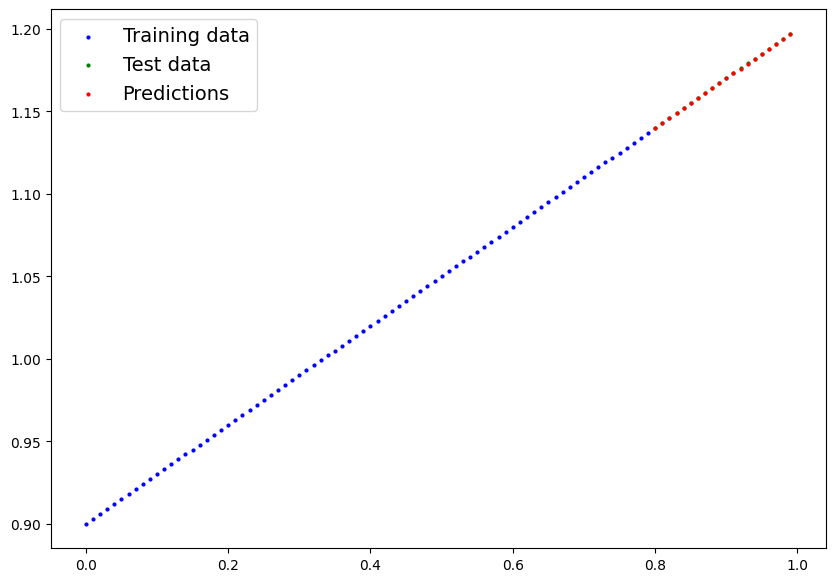

In [19]:
model_1.eval()

with torch.inference_mode():
  y_preds = model_1(X_test)

plot_predictions(predictions = y_preds.cpu())


In [20]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents = True,exist_ok = True)

MODEL_NAME = "Linear_regression_Model"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

torch.save(obj = model_1.state_dict(),f =MODEL_SAVE_PATH)